In [4]:
!pip install numpy==1.24.3
!pip install --user scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [1]:
import sys
print("Python executable being used:", sys.executable)
print("Python version:", sys.version)


Python executable being used: /usr/bin/python3
Python version: 3.10.12 (main, Nov  6 2024, 20:22:13) [GCC 11.4.0]


In [5]:
!/usr/bin/python3 -m pip install scikit-learn
!/usr/bin/python3 -m pip install numpy==1.24.3

Defaulting to user installation because normal site-packages is not writeable
DEPRECATION: distro-info 1.1build1 has a non-standard version number. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of distro-info or contact the author to suggest that they release a version with a conforming version number. Discussion can be found at https://github.com/pypa/pip/issues/12063
DEPRECATION: python-debian 0.1.43ubuntu1 has a non-standard version number. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of python-debian or contact the author to suggest that they release a version with a conforming version number. Discussion can be found at https://github.com/pypa/pip/issues/12063

[notice] A new release of pip is available: 24.0 -> 24.3.1
[notice] To update, run: pip3.10 install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━

In [7]:
import seaborn as sns
import sklearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

In [8]:
dataset = pd.read_csv('Dataset/Dataset.csv') 
dataset.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [9]:
dataset.isnull().sum()


Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [10]:
# Fill missing values for categorical columns with mode
categorical_columns = ['Gender', 'Married', 'Dependents', 'Self_Employed']
for col in categorical_columns:
    dataset[col].fillna(dataset[col].mode()[0], inplace=True)

# Fill missing values for numerical columns with medium/mode
dataset['LoanAmount'].fillna(dataset['LoanAmount'].median(), inplace=True)
dataset['Loan_Amount_Term'].fillna(dataset['Loan_Amount_Term'].mode()[0], inplace=True)
dataset['Credit_History'].fillna(dataset['Credit_History'].mode()[0], inplace=True)

dataset.isnull().sum()


Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

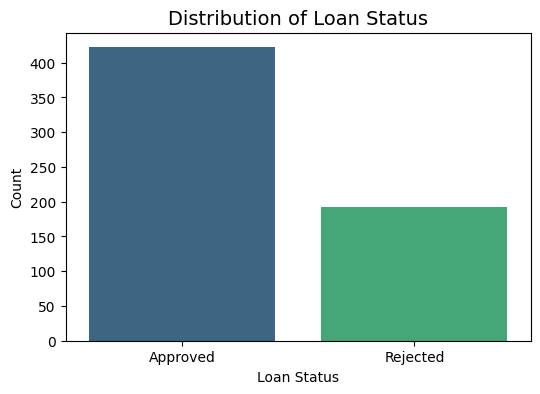

In [11]:
dataset['Loan_Status'] = dataset['Loan_Status'].map({'Y': 'Approved', 'N': 'Rejected'})

# Plot the distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Loan_Status', data=dataset, palette='viridis')
plt.title('Distribution of Loan Status', fontsize=14)
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()


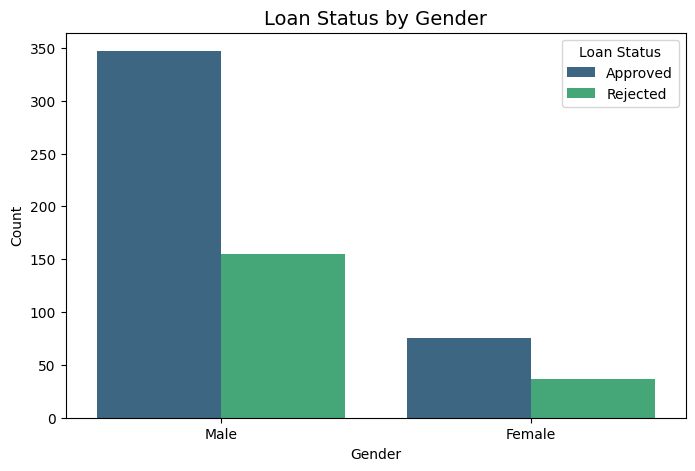

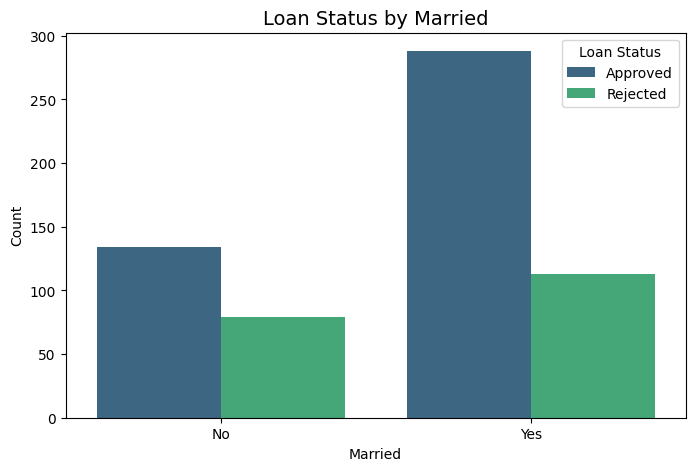

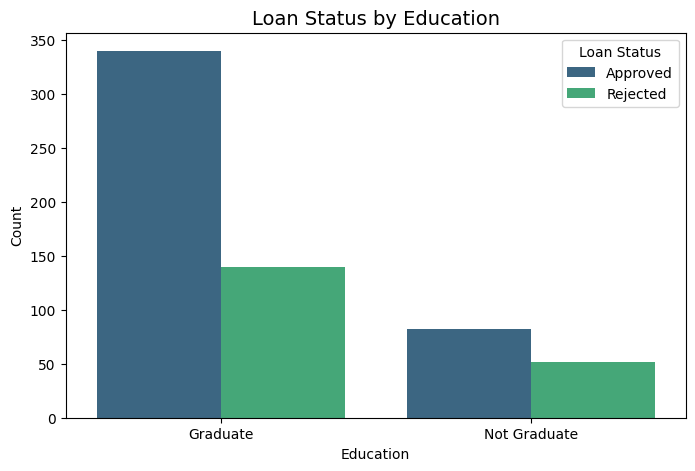

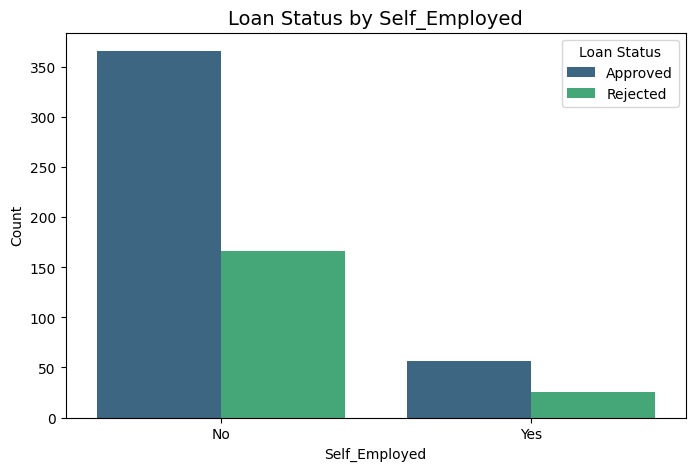

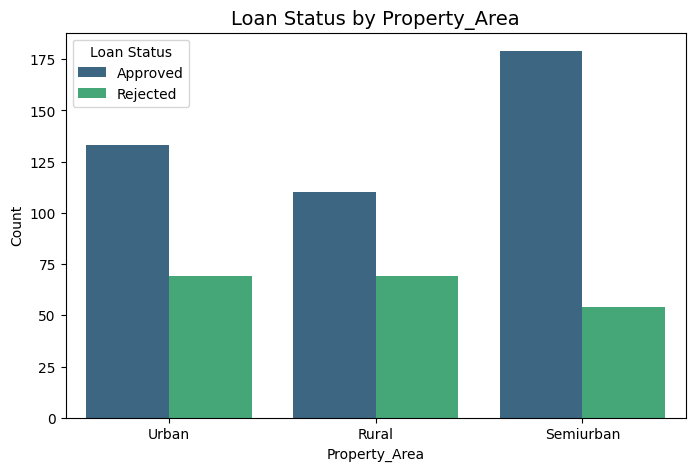

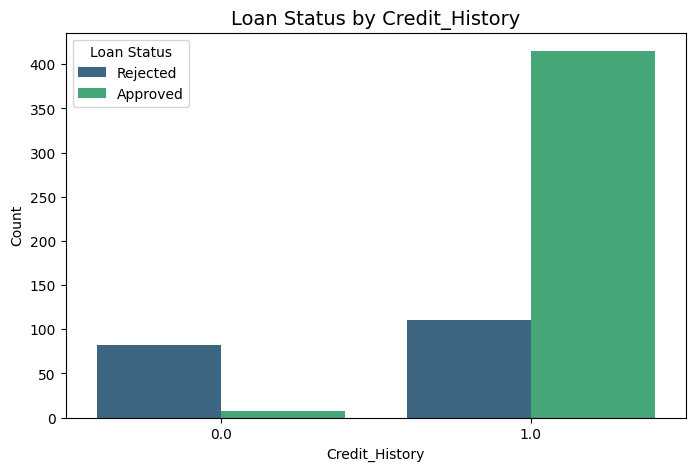

In [12]:
categorical_features = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Credit_History']

for feature in categorical_features:
    plt.figure(figsize=(8, 5))
    sns.countplot(x=feature, hue='Loan_Status', data=dataset, palette='viridis')
    plt.title(f'Loan Status by {feature}', fontsize=14)
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.legend(title='Loan Status')
    plt.show()


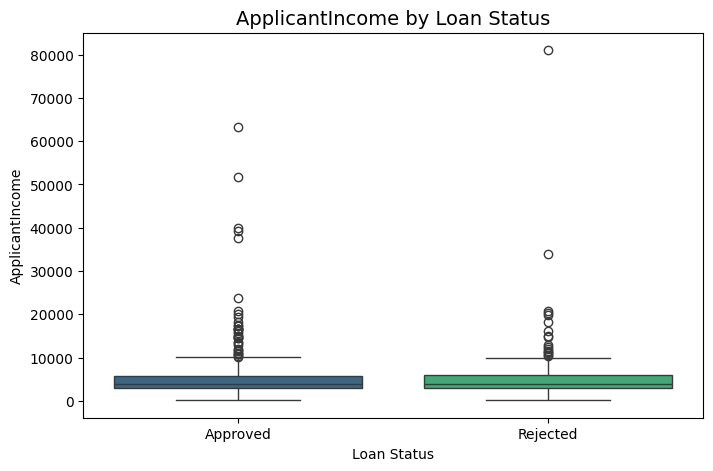

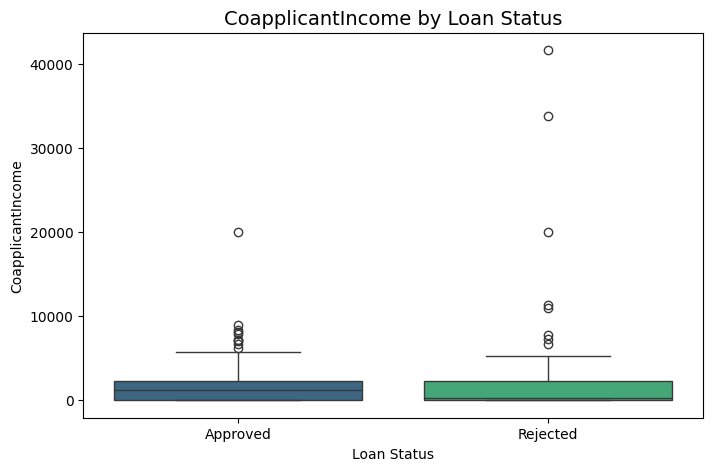

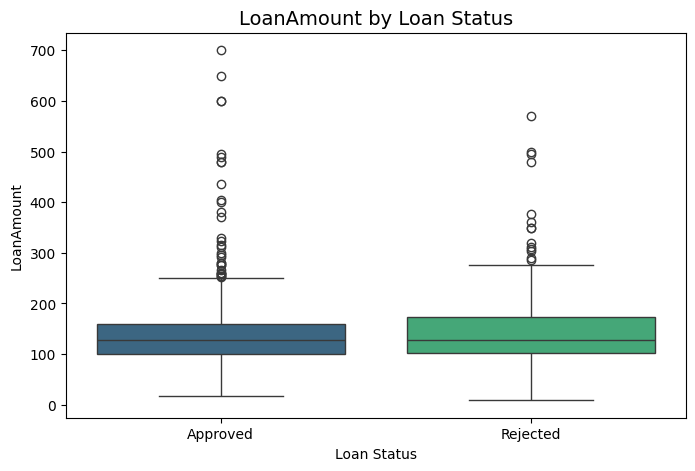

In [13]:
numerical_features = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']

for feature in numerical_features:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='Loan_Status', y=feature, data=dataset, palette='viridis')
    plt.title(f'{feature} by Loan Status', fontsize=14)
    plt.xlabel('Loan Status')
    plt.ylabel(feature)
    plt.show()


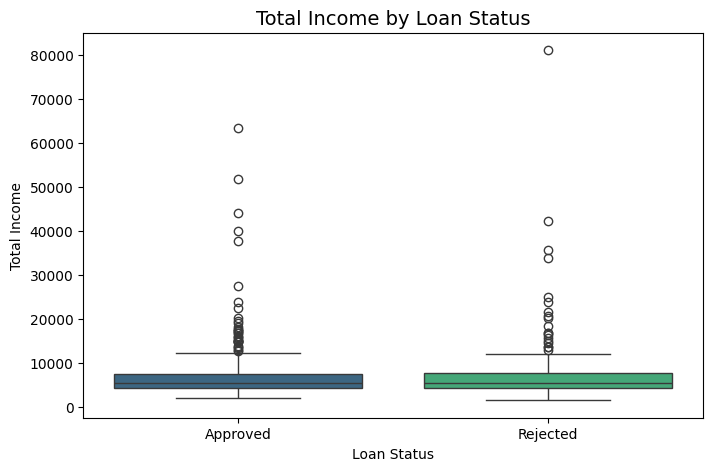

In [14]:
dataset['TotalIncome'] = dataset['ApplicantIncome'] + dataset['CoapplicantIncome']

plt.figure(figsize=(8, 5))
sns.boxplot(x='Loan_Status', y='TotalIncome', data=dataset, palette='viridis')
plt.title('Total Income by Loan Status', fontsize=14)
plt.xlabel('Loan Status')
plt.ylabel('Total Income')
plt.show()


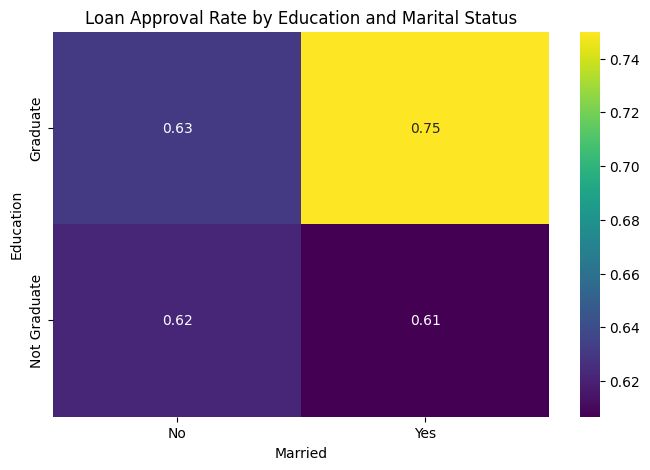

In [15]:
plt.figure(figsize=(8, 5))
sns.heatmap(pd.crosstab(dataset['Education'], dataset['Married'], values=dataset['Loan_Status'].map({'Approved': 1, 'Rejected': 0}), aggfunc='mean'), 
            annot=True, cmap='viridis', fmt='.2f')
plt.title('Loan Approval Rate by Education and Marital Status')
plt.xlabel('Married')
plt.ylabel('Education')
plt.show()

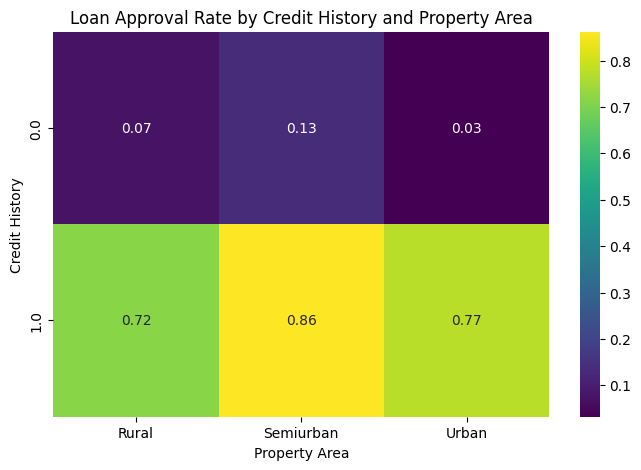

In [16]:
plt.figure(figsize=(8, 5))
sns.heatmap(pd.crosstab(dataset['Credit_History'], dataset['Property_Area'], values=dataset['Loan_Status'].map({'Approved': 1, 'Rejected': 0}), aggfunc='mean'), 
            annot=True, cmap='viridis', fmt='.2f')
plt.title('Loan Approval Rate by Credit History and Property Area')
plt.xlabel('Property Area')
plt.ylabel('Credit History')
plt.show()


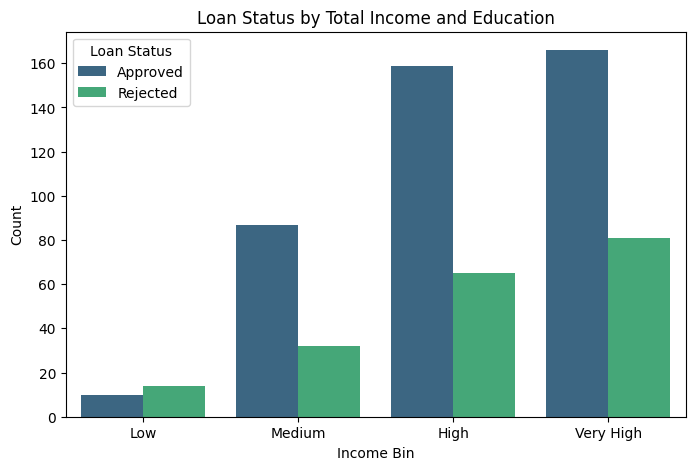

In [17]:
dataset['IncomeBin'] = pd.cut(dataset['TotalIncome'], bins=[0, 2500, 4000, 6000, 81000], labels=['Low', 'Medium', 'High', 'Very High'])

plt.figure(figsize=(8, 5))
sns.countplot(x='IncomeBin', hue='Loan_Status', data=dataset, palette='viridis')
plt.title('Loan Status by Total Income and Education')
plt.xlabel('Income Bin')
plt.ylabel('Count')
plt.legend(title='Loan Status')
plt.show()


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode categorical features
encoder = LabelEncoder()
categorical_columns = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']
for col in categorical_columns:
    dataset[col] = encoder.fit_transform(dataset[col])

# Encode target variable (Loan_Status: Approved=1, Rejected=0)
dataset['Loan_Status'] = encoder.fit_transform(dataset['Loan_Status'])

# Define features (X) and target (y)
X = dataset.drop(columns=['Loan_Status', 'Loan_ID'], axis=1)
y = dataset['Loan_Status']

# Split into training and testing datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [31]:
print(X_train.dtypes) 
print(X_train.select_dtypes(include=['object']).head())  
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
for col in X_train.select_dtypes(include=['object']).columns:
    X_train[col] = encoder.fit_transform(X_train[col])
    X_test[col] = encoder.transform(X_test[col]) 


Gender                 int64
Married                int64
Dependents             int64
Education              int64
Self_Employed          int64
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area          int64
TotalIncome          float64
dtype: object
Empty DataFrame
Columns: []
Index: [83, 90, 227, 482, 464]


In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Train the logistic regression model
logistic_model = LogisticRegression(random_state=42)
logistic_model.fit(X_train, y_train)

# Make predictions
y_pred = logistic_model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.7886178861788617

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.99      0.86        80
           1       0.95      0.42      0.58        43

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123


Confusion Matrix:
 [[79  1]
 [25 18]]


In [38]:
X = X.drop(columns=['IncomeBin'], errors='ignore')

In [39]:
def explain_loan_status(prediction):
    return "Approved" if prediction == 1 else "Rejected"

dataset['Predicted_Loan_Status'] = logistic_model.predict(X)

dataset['Loan_Status_Explanation'] = dataset['Predicted_Loan_Status'].apply(explain_loan_status)

dataset[['Loan_ID', 'Predicted_Loan_Status', 'Loan_Status_Explanation']].head()


,Loan_ID,Predicted_Loan_Status,Loan_Status_Explanation
0,LP001002,0,Rejected
1,LP001003,0,Rejected
2,LP001005,0,Rejected
3,LP001006,0,Rejected
4,LP001008,0,Rejected
